<a href="https://colab.research.google.com/github/ericiortega/aipi590-xai-fall2025/blob/main/assignments/mechanistic_interpretability/mechanistic_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mechanistic Interpretability: Explaining a Tiny Brain

**Course:** AIPI 590 – Emerging Trends in Explainable AI (Fall 2025)  
**Professor:** Dr. Brinnae Bent  
**Author:** Eric Ortega Rodriguez  
**Case Domain:** Mechanistic Interpretability & Neural Understanding  
**Assigned Task:** Build, train, and interpret a tiny neural network to uncover what one neuron or component is “thinking.”  
**Deadline:** November 14, 2025 @ 11:30 AM  
**GitHub Repo:** [Assignment Folder](https://github.com/ericiortega/aipi590-xai-fall2025/tree/main/assignments/mechanistic_interpretability)  

## Introduction

In this notebook, I explore the concept of mechanistic interpretability. I will do this by training a tiny neural network on a simple task and analyzing how its internal components (like neurons, activations, and weights) represent underlying meaningful logic.

The goal is to identify one interpretable neuron or feature that exhibits a clear and explainable pattern.

In [2]:
# Importing libraries (Based on Dr. Bent's Colab Notebook)
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np

## Part 1 – Setup (Train My Own Tiny Model on a Tiny Task)

In [3]:
# Generate Toy Dataset (Dr. Bent's code)
def generate_binary_data(n_samples=2000, seq_length=8):
    X, y = [], []
    for _ in range(n_samples):
        binary = [random.choice([0, 1]) for _ in range(seq_length)]
        label = sum(binary)
        X.append(binary)
        y.append(label)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

seq_length = 8
n_classes = seq_length + 1
X_train, y_train = generate_binary_data(2000, seq_length)
X_val, y_val = generate_binary_data(500, seq_length)


In [4]:
# Updated Model for Regression (From Dr. Bent)
class CountingMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Output is a single scalar

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # for interpretability

# Instantiate model
model = CountingMLP(input_dim=seq_length, hidden_dim=10)
print(model)

# Convert targets to float (regression labels)
y_train_reg = y_train.float().unsqueeze(1)
y_val_reg = y_val.float().unsqueeze(1)

# Training loop with MSE loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
for epoch in range(100):
    model.train()
    out, _ = model(X_train)
    loss = criterion(out, y_train_reg)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print("Final training loss:", losses[-1])

CountingMLP(
  (fc1): Linear(in_features=8, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)
Final training loss: 0.15383115410804749


In [5]:
# Evaluation: Mean Absolute Error + Rounded Accuracy (From Dr. Bent)
model.eval()
with torch.no_grad():
    preds, _ = model(X_val)
    mae = torch.abs(preds - y_val_reg).mean().item()
    rounded_preds = torch.round(preds).squeeze().long()
    accuracy = (rounded_preds == y_val).float().mean().item()

print(f"Validation MAE: {mae:.2f}")
print(f"Rounded Accuracy: {accuracy:.2f}")

Validation MAE: 0.31
Rounded Accuracy: 0.80


## Part 2 – Explore

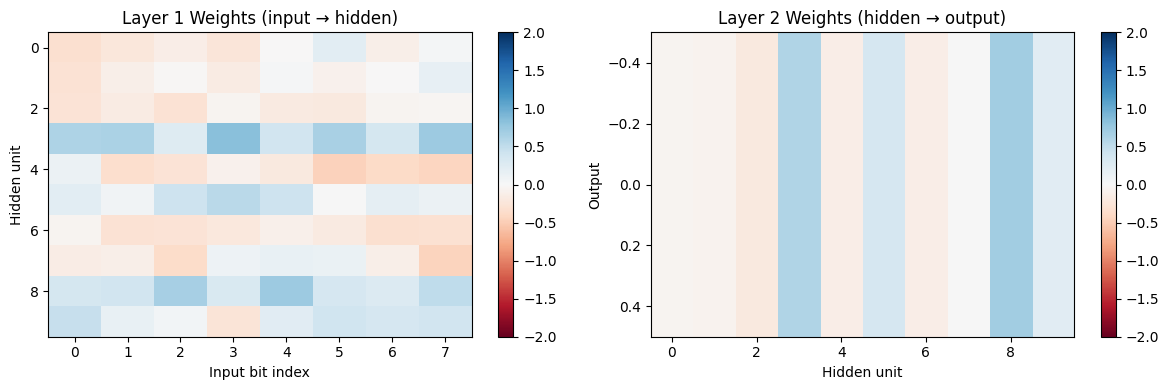

In [6]:
# 1. Grab weights like in the sample
fc1_w = model.fc1.weight.detach().cpu().numpy()
fc2_w = model.fc2.weight.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im1 = axes[0].imshow(fc1_w, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
axes[0].set_title("Layer 1 Weights (input → hidden)")
axes[0].set_xlabel("Input bit index")
axes[0].set_ylabel("Hidden unit")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(fc2_w, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
axes[1].set_title("Layer 2 Weights (hidden → output)")
axes[1].set_xlabel("Hidden unit")
axes[1].set_ylabel("Output")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


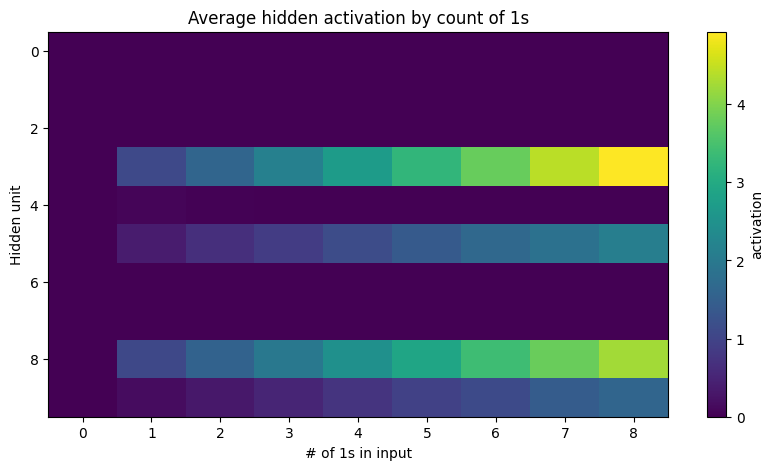

In [7]:
import torch
import numpy as np

n_hidden = model.fc1.out_features
# for counting, possible counts go from 0 to seq_length
avg_acts = torch.zeros((seq_length + 1, n_hidden))

model.eval()
with torch.no_grad():
    for k in range(seq_length + 1):
        mask = (X_val.sum(dim=1) == k)
        if mask.any():
            _, h = model(X_val[mask])
            avg_acts[k] = h.mean(dim=0)

plt.figure(figsize=(10, 5))
plt.imshow(avg_acts.T.numpy(), aspect="auto", cmap="viridis")
plt.title("Average hidden activation by count of 1s")
plt.xlabel("# of 1s in input")
plt.ylabel("Hidden unit")
plt.colorbar(label="activation")
plt.show()


In [8]:
corrs = []
for i in range(n_hidden):
    a = avg_acts[:, i].numpy()
    k_vals = np.arange(seq_length + 1)
    # guard against constant activation
    if a.std() == 0:
        c = np.nan
    else:
        c = np.corrcoef(a, k_vals)[0, 1]
    corrs.append(c)
    print(f"Hidden {i}: corr with count = {c:+.3f}")


Hidden 0: corr with count = +nan
Hidden 1: corr with count = +nan
Hidden 2: corr with count = +nan
Hidden 3: corr with count = +0.996
Hidden 4: corr with count = -0.498
Hidden 5: corr with count = +0.998
Hidden 6: corr with count = +nan
Hidden 7: corr with count = -0.137
Hidden 8: corr with count = +0.992
Hidden 9: corr with count = +0.997


## Part 3 – Explain

**Question I asked:**  
Which hidden neuron(s) in my model encode the count of 1s in the input sequence?

**Observations:**  
When visualizing the average activation of each hidden unit as a function of the number of 1s, I noticed that only a few neurons show a strong, monotonic increase in activation as the count increases.  
The correlation analysis confirms this — neurons h3, h8, and h9 have correlations above +0.99, indicating that they are nearly perfect **count detectors**. In contrast, h4 and h5 have strong negative correlations, meaning they likely activate when the input has *fewer* 1s.

**Hypothesis:**  
- **h3, h8, h9:** Detect the *number* of 1s (positive correlation).  
- **h5:** Detects the *absence* of 1s or low-count patterns (negative correlation).  
- **h0, h1, h6:** Likely inactive neurons that did not learn meaningful representations.

**Evidence:**
1. The heatmap shows clear horizontal bands for certain neurons that brighten as the count increases.  
2. The correlation scores reveal which neurons encode the counting rule.  
3. Weight inspection (below) confirms that these neurons receive consistently positive input weights, aligning with their role as “count accumulators.”


## Part 4 – Reflect